## LangGraph의 Human-in-the-loop(HITL)
- AI는 100%의 정확도를 보장하지 않기 때문에, 경우에 따라 사람의 개입이 필요합니다
- LangGraph의 `interrupt`를 사용하여 사람의 개입을 처리할 수 있습니다

### 1. `interrupt()`: 실행의 일시 정지와 데이터 수신

`interrupt`는 그래프의 흐름을 물리적으로 멈추고 외부 사용자의 개입을 기다리는 **체크포인트 호출기**입니다.

* **주요 동작**
1. 현재 `State`를 체크포인트에 저장하고 실행을 즉시 중단합니다.
2. 인자로 전달한 데이터(질문, 도구 호출 정보 등)를 외부 UI로 노출합니다.
3. 사용자가 `resume`을 통해 데이터를 보내면, **중단된 그 지점부터 다시 실행**됩니다.


* **반환값**
- 사용자가 `resume` 시점에 전달한 객체(주로 `dict`)를 그대로 반환합니다.
- 예: `human_review = interrupt({...})` → `human_review`는 사용자가 보낸 `{ 'action': '...', 'data': '...' }`가 됩니다.



### 2. `Command`: 노드의 자율적인 제어권
- `Command`는 노드가 실행을 마치며 엔진에 내리는 **최종 작업 지시서**입니다. 
- 기존의 복잡한 엣지(Edge) 설정을 노드 내부로 가져온 랭그래프의 현대적인 방식입니다.
    - 원래대로라면 노드에서 변경할 데이터를 리턴하여 수정/저장하고, 
    - conditional_edge를 만들어서 어디로 갈지 복잡하게 설계해야 했지만, 
    - Command를 쓰면 노드 안에서 "데이터 저장 + 다음 행선지 결정"을 한 번에 끝낼 수 있습니다.
    
```python
return Command(
    # 1. 상태(State)를 이렇게 업데이트해!
    update={'messages': [HumanMessage(content=result['messages'][-1].content, 
    # 2. 그리고 다음엔 이 노드로 가!
    goto='supervisor',
    name='market_research')]},
)
```
* **`update` (상태 갱신)**: `State`의 특정 필드 값을 변경하거나 추가합니다.
* **`goto` (경로 결정)**: 다음에 실행할 노드 이름을 지정합니다. (라우팅 함수 대체)
* **Reducer 원리**: state에 messages가 `Annotated[list, add_messages]`로 정의 되어 있다면, 메시지의 `id`가 같을 경우 **수정**, 없을 경우 **추가**로 자동 처리됩니다.


### 3. `human_review` 노드 로직 상세 분석

사용자가 선택한 `action`에 따라 그래프의 운명이 결정됩니다.

| 사용자 선택 (`action`) | 처리 로직 (`update`) | 다음 목적지 (`goto`) | 의도 |
| --- | --- | --- | --- |
| **`continue`** | 없음 (변경 안 함) | `'tools'` | "AI의 판단이 맞으니 그대로 도구 실행해!" |
| **`update_args`** | `AIMessage`의 `args` 수정 | `'tools'` | "도구는 쓰되, 파라미터(인자)만 내가 고칠게." |
| **`update_tool`** | `ToolMessage` 직접 생성 | `'agent'` | "도구 실행 생략하고, 내가 결과값(data)을 바로 줄게." |

**주의사항**:
1. `interrupt`를 사용하려면 그래프 생성 시 반드시 **checkpointer**가 설정되어 있어야 합니다.
2. `tool_calls[-1]` 방식은 멀티 도구 호출 시 데이터 유실 위험이 있으므로, 실제 운영 환경에서는 전체 리스트를 순회하며 처리하는 것이 안전합니다.


### 4. 전체 데이터 흐름 (Workflow)

1. **Agent**: 도구 호출이 포함된 `AIMessage` 생성.
2. **human_review**: `interrupt` 발생 → 실행 중단 및 대기.
3. **User**: UI에서 내용을 확인하고 수정 후 `resume` 전송.
4. **human_review**: 중단 지점에서 재개, 입력받은 값으로 `Command` 생성 및 반환.
5. **Graph Engine**: `Command`의 지시대로 `State`를 업데이트하고 지정된 노드로 이동.

In [1]:
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

load_dotenv()

llm = ChatOpenAI(model='gpt-4o')
small_llm = ChatOpenAI(model='gpt-4o-mini')

In [2]:
from langchain_core.tools import tool

@tool 
def add(a: int, b:int) -> int:
    """숫자 a와 b를 더합니다.""" 
    return a + b

@tool
def multiply(a: int, b:int) -> int:
    """숫자 a와 b를 곱합니다."""
    return a * b

In [3]:
from langchain_community.tools import DuckDuckGoSearchRun

web_search_tool = DuckDuckGoSearchRun()

In [4]:
from langchain_google_community import GmailToolkit
from langchain_google_community.gmail.utils import (
    build_resource_service,
    get_gmail_credentials,
)

# Can review scopes here https://developers.google.com/gmail/api/auth/scopes
# For instance, readonly scope is 'https://www.googleapis.com/auth/gmail.readonly'
credentials = get_gmail_credentials(
    token_file="../google/token.json", #나중에 만들어지는 파일 
    scopes=["https://mail.google.com/"],
    client_sercret_file="../google/credentials.json",
)

api_resource = build_resource_service(credentials=credentials)
gmail_toolkit = GmailToolkit(api_resource=api_resource)
gmail_tool_list = gmail_toolkit.get_tools()

#app publish, gmail API 승인 필요 

/var/folders/h2/84bkz1z16w5c0lv50z7fjm_40000gn/T/ipykernel_30366/1023507223.py:9: DeprecationWarning: get_gmail_credentials is deprecated and will be removed in a future version.Use get_google_credentials instead.
  credentials = get_gmail_credentials(
/var/folders/h2/84bkz1z16w5c0lv50z7fjm_40000gn/T/ipykernel_30366/1023507223.py:15: DeprecationWarning: build_resource_service is deprecated and will be removed in a future version.Use build_gmail_service instead.
  api_resource = build_resource_service(credentials=credentials)


In [5]:
from langchain_community.tools.arxiv.tool import ArxivQueryRun
from langchain_community.utilities.arxiv import ArxivAPIWrapper

arxiv_tool = ArxivQueryRun(api_wrapper=ArxivAPIWrapper())

In [6]:
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.tools.retriever import create_retriever_tool

embeddings = OpenAIEmbeddings(model='text-embedding-3-large')
vector_store = Chroma(
    embedding_function=embeddings,
    collection_name = 'real_estate_tax',
    persist_directory='../real_estate_tax_collection'
)

retriever = vector_store.as_retriever(search_kwargs={'k': 3})

retriever_tool = create_retriever_tool(
    retriever=retriever,
    name='real_estate_tax_retriever',
    description="2024년 12월까지의 부동산 세금(취득세, 보유세, 양도소득세 등) 정보를 포함하고 있습니다. 부동산 세금 관련 법령이나 계산 방식에 대한 질문이 들어오면 이 도구를 사용하세요.",
)

In [7]:
from langgraph.prebuilt import ToolNode

#함수 객체 리스트 정의 
tool_list = [add, multiply, web_search_tool, arxiv_tool, retriever_tool] + gmail_tool_list

#모델에 도구 설명서 전달 
llm_with_tools = small_llm.bind_tools(tool_list)

#함수 객체 리스트를 전달받아, llm의 도구 호출 지시에 따라 실제로 파이썬 함수를 실행하는 노드를 생성
tool_node = ToolNode(tool_list)

In [8]:
from langgraph.graph import MessagesState

# MessagesState 상속 받은 State 정의 
class AgentState(MessagesState):
    #messages: Annotated[List[AnyMessage], add_messages]
    summary: str #지난 message를 요약하여 저장해두는 곳 

In [9]:
from langchain_core.messages import SystemMessage

def agent(state: AgentState) -> AgentState:
    """
    에이전트 함수는 주어진 상태에서 메시지를 가져와
    LLM과 도구를 사용하여 응답 메시지 (AIMessage)를 생성합니다.

    Args:
        state (AgentState): 메시지 기록과 요약을 포함하는 state.

    Returns:
        MessagesState: 응답 메시지를 포함하는 새로운 state.
    """
    # 상태에서 메시지와 요약을 추출 
    messages = state['messages']
    summary = state['summary']

    # 요약이 비어있지 않으면, 메시지 리스트 앞에 요약 내용을 추가합니다.
    if summary != '':
        content = f'이전 대화 내용 요약: {summary}' 
        messages = [SystemMessage(content=content)] + messages       

    # LLM과 도구를 사용하여 메시지를 처리하고 응답을 생성합니다.
    response = llm_with_tools.invoke(messages)
    
    # 응답 메시지를 새로운 상태로 반환합니다.
    return {'messages': [response]}

In [10]:
from typing import Literal
from langgraph.types import interrupt, Command

def human_review(state: AgentState) -> Command[Literal['tools', 'agent']]:
    """
    human_review node는 LLM의 도구 호출에 대해 사람의 검토를 요청합니다.

    Args:
        state (AgentState): 메시지 기록을 포함하는 state.

    Returns:
        Command: 다음 node로 이동하기 위한 Command를 반환합니다.
    """
    messages = state['messages']
    last_message = messages[-1]
    tool_call = last_message.tool_calls[-1]
    human_review = interrupt({
        'question': '이렇게 진행하면 될까요?',
        'tool_call': tool_call
    })
    review_action = human_review['action']
    review_data = human_review.get('data', None)
    
    if review_action == 'continue':
        # 에이전트의 판단이 맞다면, 도구를 사용하기 위해 아무것도 수정하지 않고 `tools` 노드로 이동합니다
        return Command(goto='tools')
    
    if review_action == 'update_args':
        # 도구를 더 효율적으로 사용하기 위해 AIMessage의 `tool_calls` 필드를 업데이트합니다
        updated_ai_message = {
            'id': last_message.id,
            'role': 'ai',
            'content': last_message.content,
            'tool_calls': [{
                'id': tool_call['id'],
                'name': tool_call['name'],
                'args': review_data
            }],
        }
        return Command(goto='tools', update={'messages': [updated_ai_message]})
    
    if review_action == 'update_tool':
        # 다른 도구를 사용하기 위해 `ToolMessage`를 업데이트합니다 
        updated_tool_message = {
            'tool_call_id': tool_call['id'],
            'name': tool_call['name'],
            'role': 'tool',
            'content': review_data
        }
        return Command(goto='agent', update={'messages': [updated_tool_message]})


In [11]:
def summarize_messages(state: AgentState) -> AgentState:
    """
    주어진 state의 메시지를 요약합니다.

    Args:
        state (AgentState): 메시지와 요약을 포함하는 state.

    Returns:
        AgentState: 요약된 메시지를 포함하는 딕셔너리.
    """
    # state에서 메시지와 요약을 가져옵니다.
    messages = state['messages']
    summary = state['summary']
    
    summary_prompt = f'다음 대화 기록을 간결하게 요약해 주세요.\n\nchat_history:{messages}'

    # 요약 프롬프트를 생성합니다.
    if summary != '':
        summary_prompt = f'''아래의 최근 대화 내용과 이전의 대화 내용을 모두 참고하여 핵심적인 대화 내용을 간단히 요약해 주세요.
chat_history:{messages}
summary:{summary}'''
    
    # LLM을 사용하여 요약을 생성합니다.
    summary = small_llm.invoke(summary_prompt)
    
    # 요약된 메시지를 반환합니다.
    return {'summary': summary.content}

In [12]:
from langchain_core.messages import RemoveMessage

def delete_messages(state: AgentState) -> AgentState:
    """
    주어진 state에서 오래된 메시지를 삭제합니다.

    Args:
        state (AgentState): 메시지를 포함하는 state.

    Returns:
        AgentState: 삭제된 메시지를 포함하는 새로운 state.
    """
    # state에서 메시지를 가져옵니다.
    messages = state['messages']
    
    # 마지막 세 개의 메시지를 제외한 나머지 메시지를 삭제합니다.
    delete_messages = [RemoveMessage(id=message.id) for message in messages[:-3]]
    # 삭제된 메시지를 포함하는 새로운 state를 반환합니다.
    return {'messages': delete_messages}

In [13]:
def should_continue(state: MessagesState):
    """
    주어진 state에 따라 다음 단계로 진행할지를 결정합니다.

    Args:
        state (AgentState): 메시지와 도구 호출 정보를 포함하는 state.

    Returns:
        Literal['tools', 'summarize_messages']: 다음 단계로 'tools' 또는 'summarize_messages'를 반환합니다.
    """
    messages = state['messages']
    last_ai_message = messages[-1]
    if last_ai_message.tool_calls:
        return 'human_review'
    
    return 'summarize_messages'

In [14]:
from langgraph.graph import MessagesState, StateGraph
graph_builder = StateGraph(AgentState)

graph_builder.add_node('agent', agent)
graph_builder.add_node('tools', tool_node)
graph_builder.add_node(human_review)
graph_builder.add_node(delete_messages)
graph_builder.add_node(summarize_messages)

In [15]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'agent')

graph_builder.add_conditional_edges(
    'agent',
    should_continue, 
    ['human_review', 'summarize_messages'] 
)
graph_builder.add_edge('tools', 'agent')
graph_builder.add_edge('summarize_messages', 'delete_messages')
graph_builder.add_edge('delete_messages', END)

In [16]:
from langgraph.checkpoint.memory import MemorySaver

# 1. 기억 저장소(창고) 객체를 만듭니다.
checkpointer = MemorySaver()

# 2. 그래프를 컴파일할 때 이 저장소를 연결합니다.
graph = graph_builder.compile(
    checkpointer = checkpointer
)

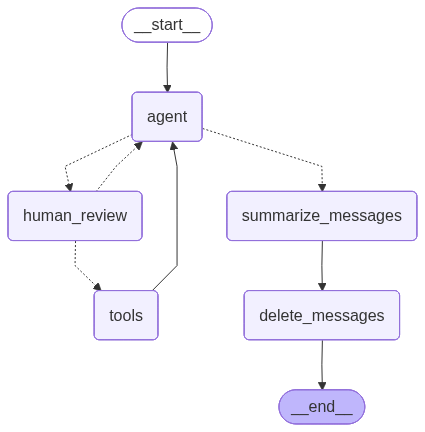

In [17]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [18]:
from langchain.messages import HumanMessage

# 3. 특정 대화방을 구분할 번호표(thread_id)를 정합니다.
config = {
    'configurable': {
        'thread_id': 'summarize_paper'  # 대화방 별 고유 이름
    }
}

query = "'LLM Survey 논문의 내용을 검색해서 요약해주세요'"

# 4. 실행할 때 이 config를 함께 전달합니다.
for chunk in graph.stream({'messages': [HumanMessage(query)],'summary': ''}, config=config, stream_mode='values'):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

'LLM Survey 논문의 내용을 검색해서 요약해주세요'
================================== Ai Message ==================================
Tool Calls:
  arxiv (call_969cdZQPazezj5SJTaI9OS6J)
 Call ID: call_969cdZQPazezj5SJTaI9OS6J
  Args:
    query: LLM Survey
================================== Ai Message ==================================
Tool Calls:
  arxiv (call_969cdZQPazezj5SJTaI9OS6J)
 Call ID: call_969cdZQPazezj5SJTaI9OS6J
  Args:
    query: LLM Survey


In [22]:
message_list = graph.get_state(config).values['messages']
summary = graph.get_state(config).values['summary']
message_list
#summary

[HumanMessage(content="'LLM Survey 논문의 내용을 검색해서 요약해주세요'", additional_kwargs={}, response_metadata={}, id='e36abd64-0a7f-4139-aa4a-8db7468f6689'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 804, 'total_tokens': 820, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_373a14eb6f', 'id': 'chatcmpl-DFGEtosaD3hwAlAbtvcQNPtCJfGip', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cb301-02cc-70c0-94f9-c060ef4a1d1c-0', tool_calls=[{'name': 'arxiv', 'args': {'query': 'LLM Survey'}, 'id': 'call_969cdZQPazezj5SJTaI9OS6J', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 804, 'output_tokens'

In [23]:
for chunk in graph.stream(
    Command(resume={"action": "update_tool", "data": "arxiv말고 web에서 검색해주세요"}),
    config,
    stream_mode="updates",
): 
    print(chunk)

{'human_review': {'messages': [{'tool_call_id': 'call_969cdZQPazezj5SJTaI9OS6J', 'name': 'arxiv', 'role': 'tool', 'content': 'arxiv말고 web에서 검색해주세요'}]}}
{'agent': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 836, 'total_tokens': 859, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_6d6670c036', 'id': 'chatcmpl-DFGFNZIjUO0Fd150jNlwLEfKBzkeS', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cb301-7b00-76a2-b838-a2c17e6afde0-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'LLM Survey 논문 요약'}, 'id': 'call_smG84b0GPgz1ZRnkyJAxoKFk', 'type': 'tool_call'}], invalid_tool_calls=[], usage

In [24]:
message_list = graph.get_state(config).values['messages']
summary = graph.get_state(config).values['summary']
message_list
#summary

[HumanMessage(content="'LLM Survey 논문의 내용을 검색해서 요약해주세요'", additional_kwargs={}, response_metadata={}, id='e36abd64-0a7f-4139-aa4a-8db7468f6689'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 804, 'total_tokens': 820, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_373a14eb6f', 'id': 'chatcmpl-DFGEtosaD3hwAlAbtvcQNPtCJfGip', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cb301-02cc-70c0-94f9-c060ef4a1d1c-0', tool_calls=[{'name': 'arxiv', 'args': {'query': 'LLM Survey'}, 'id': 'call_969cdZQPazezj5SJTaI9OS6J', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 804, 'output_tokens'

In [25]:
for chunk in graph.stream(
    Command(resume={"action": "continue"}),
    config,
    stream_mode="updates",
):
    print(f'chunk == {chunk}')

Impersonate 'safari_16.5' does not exist, using 'random'


chunk == {'human_review': None}
chunk == {'tools': {'messages': [ToolMessage(content='논문을 읽다보면 초록을 기반으로 논문 내용을 요약할 일이 생긴다. 그럴 때는 노트북 LLM 이 꽤 유용하다. 파일을 집어넣으면 자동으로 핵심만 요약해주기 때문이다.노트북 LLM 은 직접 문서나 유튜브 링크 등을 업로드한하면 요약, 질문에 대한 응답 등 기능을 수행한다. 구글의 Gemini 계열 대규모 언어 ... 요약 본 보고서는 대규모 언어 모델 ( LLM )을 활용하여 소비자 설문조사를 시뮬레이션할 때 발생하는 핵심적인 문제점을 해결하기 위한 새로운 방법론을 제시한 연구 논문 " LLMs Reproduce Human Purchase Intent via Semantic Similarity" (arXiv:2510.08338v1)를 심층적으로 분석한다. 김유미 / 경북대학교 / LLM 을 활용한 학술 자료 요약의 품질 분석 및 평가 프레임워크 개발 / 40,000 / 24개월 / 2025 박사과정생연구장려금지원사업 연구목표: 본 연구는 대규모 언어 모델 ( LLM )을 활용한 학술 논문 요약의 성능을 평가하고, 요약 품질에 영향을 미치는 주요 요인을 분석하여 신뢰성 있는 LLM ... 매일 쏟아지는 보고서, 논문, 긴 이메일의 홍수 속에서 중요한 정보만 빠르게 파악하고 싶으신가요? 대규모 언어 모델( LLM )의 문서 요약 기능은 단순한 시간 절약을 넘어, 정보의 핵심을 꿰뚫는 강력한 무기가 될 수 있어요. 이 글에서는 LLM 의 요약 능력을 200% 활용하여 누구나 \'3줄 요약의 달인\'이 되는 ... 요약 작업에서 LLM 을 최대한 활용하는 가이드 이 글은 AI 번역본입니다. 오역이 의심되면 댓글로 알려 주세요. Made by Brett Young using Weights & Biases', name='duckduckgo_search', id='443a0815-54ca-4715-8d94-0798f6f0d6

In [26]:
message_list = graph.get_state(config).values['messages']
summary = graph.get_state(config).values['summary']
message_list
#summary

[AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 836, 'total_tokens': 859, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_6d6670c036', 'id': 'chatcmpl-DFGFNZIjUO0Fd150jNlwLEfKBzkeS', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cb301-7b00-76a2-b838-a2c17e6afde0-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'LLM Survey 논문 요약'}, 'id': 'call_smG84b0GPgz1ZRnkyJAxoKFk', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 836, 'output_tokens': 23, 'total_tokens': 859, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning